# Performance Analysis - Removal of Flagged Samples

In [35]:
import numpy as np 
import pandas as pd 
import os
import matplotlib.pyplot as plt 
from PIL import Image
from src.data import augment_embeddings
from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import joblib
from tqdm import tqdm
import random

## Performance as we remove flagged data? 

### Flagged Issues

In [ ]:
df = pd.read_csv("../../outputs/analysis/data_quality/label_issues.csv")
df.sort_values(by = "confidence_in_given", ascending = False)

df_issues = df[df["given_label"] != df["suggested_label"]]
df_issues

min_conf_given = np.min(df_issues["confidence_in_given"])
max_conf_given = np.max(df_issues["confidence_in_given"])

print(f"Confidence in given varies from {min_conf_given:.2f} to {max_conf_given:.2f}")



Confidence in given varies from 0.00 to 0.47


### Preprocessing

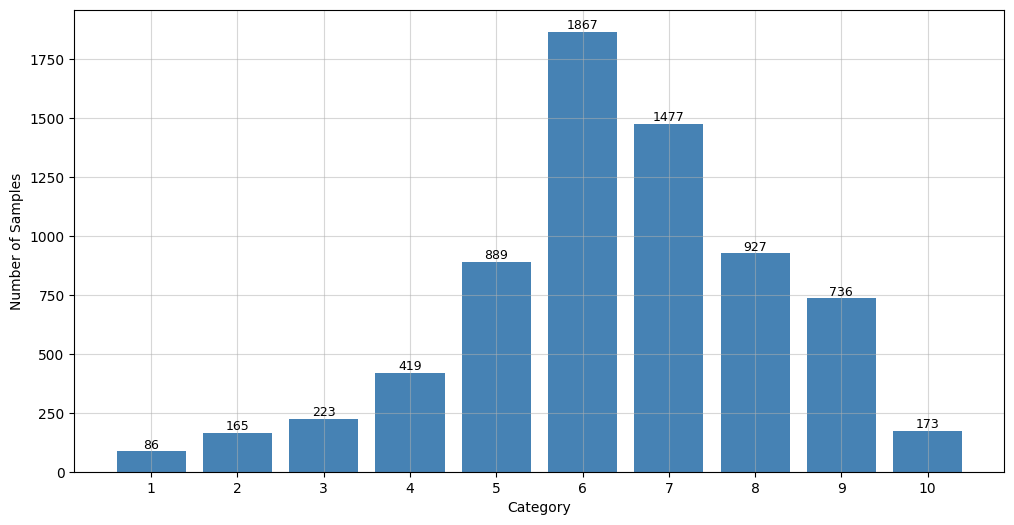

In [32]:
# Load data 
data = np.load("../../outputs/embeddings/siglip2-so400m-14-384_embeddings.npz")
features, measurements_ids, labels = data["features"], data["measurement_ids"], data["labels"]

# Selecting metadata to include in feature vector
columns = ["length","quarter_2","quarter_3","quarter_4"]
metadata_csv = "../../cod_otolith_age_final_with_quarters.csv"

features = augment_embeddings(      # Augments the feature vectors with the metadata quarters and fish length
                features, measurements_ids, metadata_csv, columns
            )



df_filter = df_issues[df_issues["confidence_in_given"] <= 0.5]
mask = np.isin(measurements_ids, df_filter["measurement_id"])
feat_clean, labels_clean = features[~mask], labels[~mask]

cat, cat_count = np.unique(labels_clean, return_counts=True)

plt.figure(figsize=(12, 6))
plt.grid(True, alpha=0.5)

bars = plt.bar(cat, cat_count,  
               color = "steelblue")

# Add count labels on top of bars
for bar, count in zip(bars, cat_count):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{count}',
             ha='center', va='bottom', fontsize=9)
    

# Set categorical labels
plt.xticks(cat, cat)
plt.xlabel('Category')
plt.ylabel('Number of Samples')
plt.show()

### Train and Testing

In [38]:
filtering_prop = [0.1, .2, .3, .4, .5]
alphas = np.logspace(1.5, 3, 50)
print(f"Alphas range: {round(alphas.min(), 2)} to {alphas.max()}")

performance = {}

seeds = random.sample(range(1, 101), 5)
print(f"Seeds used: {seeds}")

for seed in tqdm(seeds): 

    performance[seed] = {}

    for prop in filtering_prop: 

        # Filtering logic
        df_filter = df_issues[df_issues["confidence_in_given"] <= prop]
        mask = np.isin(measurements_ids, df_filter["measurement_id"])
        feat_clean, labels_clean = features[~mask], labels[~mask]

        X_train, X_test, y_train, y_test = train_test_split(feat_clean, labels_clean, test_size=0.15, stratify=labels_clean, random_state = seed)

        print(f"Train set dimension: {len(X_train)}")
        print(f"Test set dimension: {len(X_test)}")

        print("="*60)
        print("SCALING FEATURES")
        print("="*60)

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        print(f"Original feature shape: {X_train.shape}")
        print(f"Scaled feature shape: {X_train_scaled.shape}")
        print(f"Scaler fit on {X_train.shape[0]} samples")

        model = RidgeCV(alphas = alphas, cv = 5)
        model.fit(X_train_scaled, y_train)

        y_pred = model.predict(X_test_scaled)
        y_pred_class = np.clip(np.round(y_pred).astype(int), 1, 10)
        # Accuracy
        test_accuracy = accuracy_score(y_test, y_pred_class)
        print(f"{test_accuracy=:.2}%")

        performance[seed][prop] = test_accuracy

        print("="*60)
        print("="*60)
        print("="*60)

print(f"{performance=}")

Alphas range: 31.62 to 1000.0
Seeds used: [22, 47, 36, 91, 7]


  0%|          | 0/5 [00:00<?, ?it/s]

Train set dimension: 7087
Test set dimension: 1251
SCALING FEATURES
Original feature shape: (7087, 1156)
Scaled feature shape: (7087, 1156)
Scaler fit on 7087 samples
test_accuracy=0.56%
Train set dimension: 6841
Test set dimension: 1208
SCALING FEATURES
Original feature shape: (6841, 1156)
Scaled feature shape: (6841, 1156)
Scaler fit on 6841 samples
test_accuracy=0.57%
Train set dimension: 6550
Test set dimension: 1157
SCALING FEATURES
Original feature shape: (6550, 1156)
Scaled feature shape: (6550, 1156)
Scaler fit on 6550 samples
test_accuracy=0.59%
Train set dimension: 6133
Test set dimension: 1083
SCALING FEATURES
Original feature shape: (6133, 1156)
Scaled feature shape: (6133, 1156)
Scaler fit on 6133 samples
test_accuracy=0.6%
Train set dimension: 5917
Test set dimension: 1045
SCALING FEATURES
Original feature shape: (5917, 1156)
Scaled feature shape: (5917, 1156)
Scaler fit on 5917 samples


 20%|██        | 1/5 [09:24<37:37, 564.36s/it]

test_accuracy=0.63%
Train set dimension: 7087
Test set dimension: 1251
SCALING FEATURES
Original feature shape: (7087, 1156)
Scaled feature shape: (7087, 1156)
Scaler fit on 7087 samples
test_accuracy=0.57%
Train set dimension: 6841
Test set dimension: 1208
SCALING FEATURES
Original feature shape: (6841, 1156)
Scaled feature shape: (6841, 1156)
Scaler fit on 6841 samples
test_accuracy=0.58%
Train set dimension: 6550
Test set dimension: 1157
SCALING FEATURES
Original feature shape: (6550, 1156)
Scaled feature shape: (6550, 1156)
Scaler fit on 6550 samples
test_accuracy=0.58%
Train set dimension: 6133
Test set dimension: 1083
SCALING FEATURES
Original feature shape: (6133, 1156)
Scaled feature shape: (6133, 1156)
Scaler fit on 6133 samples
test_accuracy=0.6%
Train set dimension: 5917
Test set dimension: 1045
SCALING FEATURES
Original feature shape: (5917, 1156)
Scaled feature shape: (5917, 1156)
Scaler fit on 5917 samples


...

test_accuracy=0.61%
Train set dimension: 7087
Test set dimension: 1251
SCALING FEATURES
Original feature shape: (7087, 1156)
Scaled feature shape: (7087, 1156)
Scaler fit on 7087 samples
test_accuracy=0.55%
Train set dimension: 6841
Test set dimension: 1208
SCALING FEATURES
Original feature shape: (6841, 1156)
Scaled feature shape: (6841, 1156)
Scaler fit on 6841 samples
test_accuracy=0.55%
Train set dimension: 6550
Test set dimension: 1157
SCALING FEATURES
Original feature shape: (6550, 1156)
Scaled feature shape: (6550, 1156)
Scaler fit on 6550 samples
test_accuracy=0.57%
Train set dimension: 6133
Test set dimension: 1083
SCALING FEATURES
Original feature shape: (6133, 1156)
Scaled feature shape: (6133, 1156)
Scaler fit on 6133 samples
test_accuracy=0.6%
Train set dimension: 5917
Test set dimension: 1045
SCALING FEATURES
Original feature shape: (5917, 1156)
Scaled feature shape: (5917, 1156)
Scaler fit on 5917 samples


 80%|████████  | 4/5 [38:14<09:35, 575.87s/it]

test_accuracy=0.63%
Train set dimension: 7087
Test set dimension: 1251
SCALING FEATURES
Original feature shape: (7087, 1156)
Scaled feature shape: (7087, 1156)
Scaler fit on 7087 samples
test_accuracy=0.6%
Train set dimension: 6841
Test set dimension: 1208
SCALING FEATURES
Original feature shape: (6841, 1156)
Scaled feature shape: (6841, 1156)
Scaler fit on 6841 samples
test_accuracy=0.6%
Train set dimension: 6550
Test set dimension: 1157
SCALING FEATURES
Original feature shape: (6550, 1156)
Scaled feature shape: (6550, 1156)
Scaler fit on 6550 samples
test_accuracy=0.61%
Train set dimension: 6133
Test set dimension: 1083
SCALING FEATURES
Original feature shape: (6133, 1156)
Scaled feature shape: (6133, 1156)
Scaler fit on 6133 samples
test_accuracy=0.61%
Train set dimension: 5917
Test set dimension: 1045
SCALING FEATURES
Original feature shape: (5917, 1156)
Scaled feature shape: (5917, 1156)
Scaler fit on 5917 samples


100%|██████████| 5/5 [47:44<00:00, 572.92s/it]

test_accuracy=0.61%
performance={22: {0.1: 0.5555555555555556, 0.2: 0.5736754966887417, 0.3: 0.5903197925669835, 0.4: 0.6001846722068329, 0.5: 0.6287081339712919}, 47: {0.1: 0.5715427657873701, 0.2: 0.5753311258278145, 0.3: 0.5799481417458946, 0.4: 0.6048014773776547, 0.5: 0.5827751196172248}, 36: {0.1: 0.5539568345323741, 0.2: 0.5745033112582781, 0.3: 0.6050129645635264, 0.4: 0.6103416435826408, 0.5: 0.6057416267942584}, 91: {0.1: 0.548361310951239, 0.2: 0.5480132450331126, 0.3: 0.5704407951598963, 0.4: 0.6048014773776547, 0.5: 0.6258373205741626}, 7: {0.1: 0.5987210231814548, 0.2: 0.6009933774834437, 0.3: 0.6076058772687987, 0.4: 0.6066481994459834, 0.5: 0.6057416267942584}}


In [1]:
# Learning Curve
filtering_props = sorted(performance[list(performance.keys())[0]].keys())
seeds = list(performance.keys())

# Calculate mean and std for each filtering proportion
means = []
stds = []

for prop in filtering_props:
    # Get all accuracies for this proportion across all seeds
    accuracies = [performance[seed][prop] for seed in seeds]
    means.append(np.mean(accuracies))
    stds.append(np.std(accuracies))

means = np.array(means)
stds = np.array(stds)

# Create the plot
plt.figure(figsize=(10, 6))
plt.grid(True, alpha= 0.5)
# Plot mean with shaded standard deviation
plt.plot(filtering_props, means, marker='o', linewidth=2, markersize=8, label='Mean Accuracy')
plt.fill_between(filtering_props, means - stds, means + stds, alpha=0.3, label='±1 Std Dev')
plt.xlabel("Proportion of Flagged data Removed")
plt.ylabel("Test Set Accuracy")


NameError: name 'performance' is not defined

# Visual Examples

In [49]:
df_sorted = df_issues.sort_values("confidence_in_given")

for sample in df_sorted.iloc: 
    print(sample["measurement_id"], sample["given_label"], sample["suggested_label"])

24409454.0 10.0 5.0
24601200.0 5.0 9.0
24319685.0 4.0 8.0
24319683.0 5.0 8.0
24601328.0 10.0 7.0
24319679.0 5.0 8.0
23709655.0 4.0 7.0
24601207.0 10.0 7.0
24319738.0 4.0 7.0
24601203.0 5.0 8.0
24341712.0 4.0 1.0
24314544.0 5.0 8.0
24143441.0 10.0 7.0
24362256.0 5.0 8.0
23990833.0 4.0 7.0
24867678.0 3.0 6.0
24258981.0 4.0 7.0
24230452.0 10.0 7.0
23948336.0 5.0 8.0
24332972.0 10.0 7.0
24765218.0 10.0 7.0
24046000.0 4.0 7.0
24362252.0 5.0 8.0
23989840.0 3.0 5.0
24230457.0 10.0 8.0
24634552.0 5.0 7.0
24319549.0 5.0 7.0
24230447.0 10.0 8.0
24230450.0 10.0 8.0
24230442.0 10.0 8.0
23993770.0 10.0 8.0
23252978.0 10.0 8.0
24319548.0 5.0 7.0
24601329.0 10.0 8.0
24316126.0 4.0 6.0
24046175.0 5.0 7.0
24634557.0 5.0 7.0
24765606.0 1.0 3.0
23968180.0 5.0 7.0
24256060.0 5.0 7.0
24614493.0 10.0 8.0
24320286.0 5.0 7.0
24230441.0 10.0 8.0
23709647.0 3.0 5.0
24315654.0 3.0 5.0
24784433.0 5.0 7.0
24601087.0 5.0 7.0
24362261.0 4.0 6.0
24362253.0 5.0 7.0
24362246.0 4.0 6.0
24714625.0 10.0 8.0
23709645.0 5.0

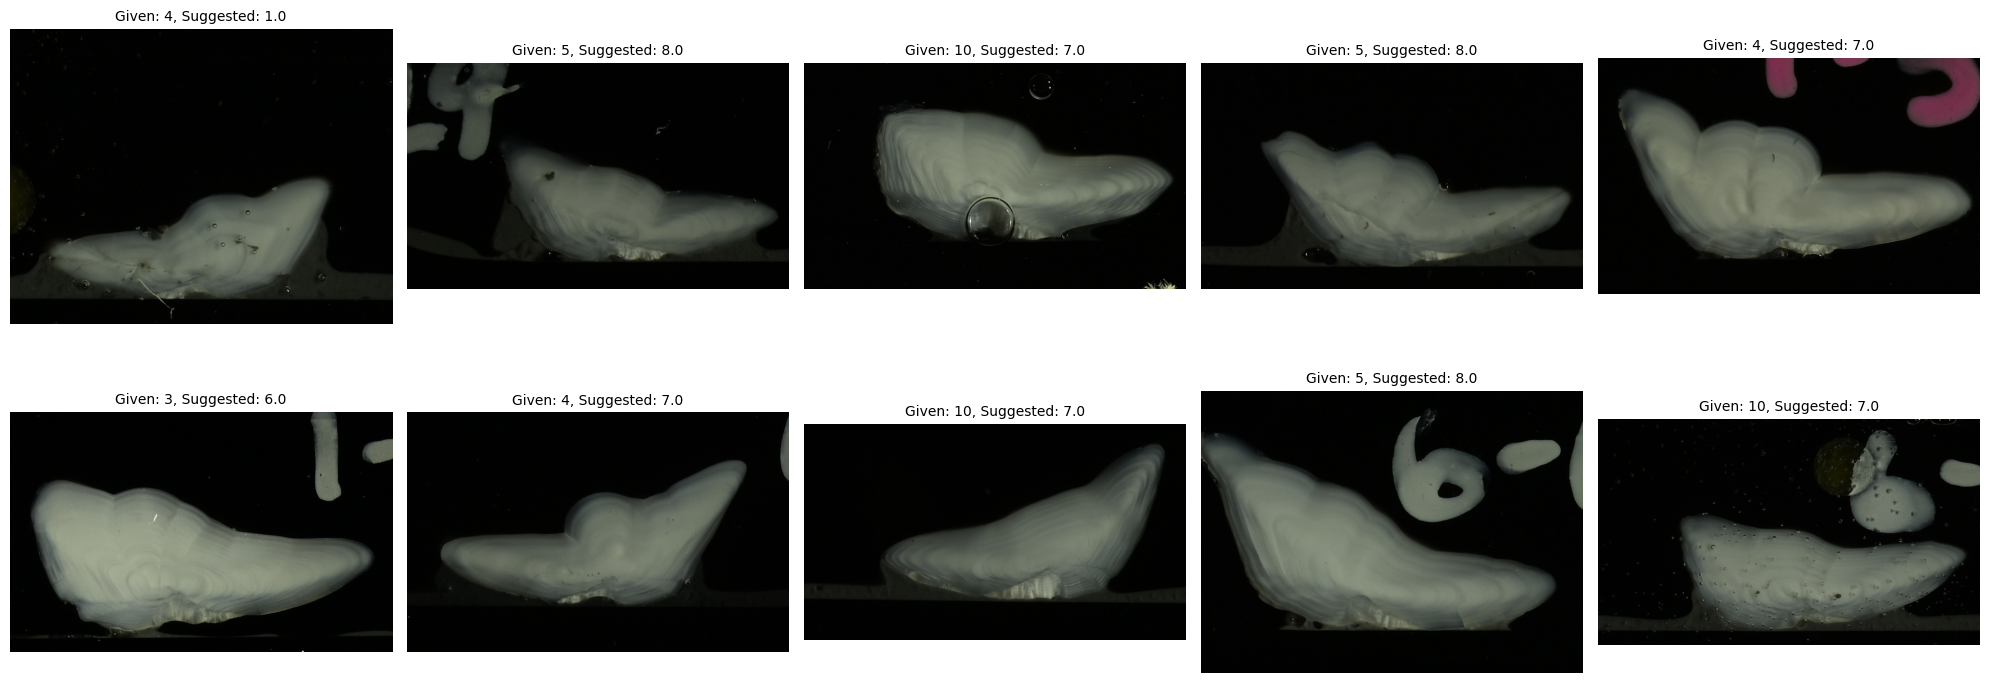

In [60]:
import matplotlib.pyplot as plt
from PIL import Image
import os
from pathlib import Path

df_sorted = df_issues.sort_values("confidence_in_given")

# Create figure with subplots
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

# Plot first 10 images
for idx, (_, sample) in enumerate(df_sorted.iloc[10:].head(10).iterrows()):
    measurement_id = int(sample["measurement_id"])
    given_age = int(sample["given_label"]) 
    suggested_age = sample["suggested_label"]
    
    # Try to find the image in any age folder
    img_path = None
    base_dir = Path("../../otolith_images")
    
    # First try the given_label folder
    candidate = base_dir / str(given_age) / f"{measurement_id}.jpg"
    if candidate.exists():
        img_path = candidate
    else:
        # Search all age folders
        for age_folder in base_dir.iterdir():
            if age_folder.is_dir():
                candidate = age_folder / f"{measurement_id}.jpg"
                if candidate.exists():
                    img_path = candidate
                    break
    
    # Load and plot image
    if img_path and img_path.exists():
        img = Image.open(img_path)
        axes[idx].imshow(img)
        axes[idx].axis('off')
        axes[idx].set_title(f"Given: {given_age}, Suggested: {suggested_age}", 
                           fontsize=10)
    else:
        axes[idx].text(0.5, 0.5, f"Image not found\n{measurement_id}", 
                      ha='center', va='center')
        axes[idx].axis('off')

plt.tight_layout()
plt.show()